# **Reading the data**
Steps:
- Importing the pandas library to read the csv dataset into a pandas dataframe
- Inspecting the dataset shape, and data types

Findings:
- The dataset shows order demand by date, product category, warehouse location, and product ID
- Contains 5 columns - 4 objects, 1 float (demand)
- Contains 1048575 entries

In [1]:
import pandas as pd

df = pd.read_csv("Product Demand.csv")
print(df.head(), "\n")

print("Shape (rows, columns):")
print(df.shape, "\n")

print("Data Types:")
print(df.dtypes)

   Product_Code  Warehouse Product_Category        Date  Order_Demand
0  Product_0965  St john's     Category_006  2014-01-08           2.0
1  Product_1724  St john's     Category_003  2014-05-31         108.0
2  Product_1521     Surrey     Category_019  2014-06-24       85000.0
3  Product_1521     Surrey     Category_019  2014-06-24        7000.0
4  Product_1507     Oshawa     Category_019  2014-09-02        1250.0 

Shape (rows, columns):
(1048575, 5) 

Data Types:
Product_Code         object
Warehouse            object
Product_Category     object
Date                 object
Order_Demand        float64
dtype: object


## EDA
Steps:
- Checking the dataset for null values, negative values
- Inspecting unique counts for product, product categories, and warehouse

Findings:
- Date column has 11239 null values - must be fixed
- Demand column contains 5997 negative entries - invalid, must be fixed
- Unique value counts show 33 unique product categories, 4 warehouses, and 2157 products

In [2]:
# Missing Values
print("Null Values per Column:")
print(df.isnull().sum())
print("\n")

# Negative Demand Rows
negative_count = (df['Order_Demand'] < 0).sum()
print("Number of Negative Demand Values:")
print(negative_count)
print("\n")

# Unique Product Categories
print("Unique Product Categories:")
print(df['Product_Category'].nunique())
print("\n")

# Unique Product Codes
print("Unique Product:")
print(df['Product_Code'].nunique())
print("\n")

# Unique Warehouses
print("Unique Warehouses")
print(df["Warehouse"].unique())

Null Values per Column:
Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64


Number of Negative Demand Values:
5997


Unique Product Categories:
33


Unique Product:
2157


Unique Warehouses
["St john's" 'Surrey' 'Oshawa' 'Brampton']


## Data Transformation
Steps:
- Removing all entries that contain a negative demand value to prepare for modelling
- Removing all entries that contain a null date value to prepare for modelling
- Converting the date column from object to datetime format
- Removing rows in which the datetime conversion did not work
- Inspecting entry counts by year, then filtering out 2014 since it has less entries

Findings:
- Removing the nulls and negatives did not affect the original shape much. The dataset is now 1000464 entries long, plenty of data to work with.

In [3]:
# Clean Dataset - Remove Negative Demand
df_clean = df[df['Order_Demand']> 0].copy()
df_clean.reset_index(drop=True, inplace=True)

# Verification
print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape, "\n")

# Check Remaining Negative Values
print("Remaining Negative Demand Values:", (df_clean['Order_Demand'] < 0).sum())

Original Shape: (1048575, 5)
Cleaned Shape: (1014027, 5) 

Remaining Negative Demand Values: 0


In [4]:
# Remove Rows with Null Dates
df_clean = df_clean[df_clean['Date'].notna()].copy()

# Verification
print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape, "\n")
print("Remaining Nulls: ")
print(df_clean.isnull().sum())

Original Shape: (1048575, 5)
Cleaned Shape: (1002797, 5) 

Remaining Nulls: 
Product_Code        0
Warehouse           0
Product_Category    0
Date                0
Order_Demand        0
dtype: int64


In [5]:
# Convert Date to datetime format
df_clean['Date'] = pd.to_datetime(df_clean['Date'],dayfirst=False, errors='coerce')
print("Date Datatype: ")
print(df_clean['Date'].dtypes, "\n")

# Counting the number of rows with incorrect date values - "NaT"
print("Df values with incorrect Date column values: ")
nat_rows = df_clean[df_clean['Date'].isna()]
print("Total Number of Rows with Incorrect Date Values: ", df_clean['Date'].isna().sum())

#Counts by year
print("\nENTRIES BY YEAR ")
year_counts = df_clean['Date'].dt.year.dropna().astype(int).value_counts().sort_index()
print(year_counts)
print(df_clean.shape)

Date Datatype: 
datetime64[ns] 

Df values with incorrect Date column values: 
Total Number of Rows with Incorrect Date Values:  1693

ENTRIES BY YEAR 
Date
2014       640
2015    198575
2016    207408
2017    210874
2018    205196
2019    178411
Name: count, dtype: int64
(1002797, 5)


In [6]:
# Filter Data - Keep Only 2015 and After
df_clean = df_clean[df_clean['Date'].dt.year >= 2015].copy()
df_clean = df_clean[df_clean['Date'].notna()].copy()

# Verification
print("Shape After Year Filter:", df_clean.shape)
print("Year Range:")
print(df_clean['Date'].dt.year.min(), "-", df_clean['Date'].dt.year.max())

Shape After Year Filter: (1000464, 5)
Year Range:
2015 - 2019



## Data Visualizations
Steps:
- importing the matplotlib and seaborn packages to be used in visualizing the data
- Converting cleaned dataframe into specific dataframes, arrays and pivot tables for ease of plotting
- Using bar charts, pie charts, a heatmap, and line charts to inspect the data and how it relates

Findings:
- When comparing the top 5 product categories by demand, there is a clear imbalance with category 019 making up 84% of all demand
- Looking at the product categories over time, it appears product 019 has always been leading. Not much change in other categories.
- When comparing the demand by warehouse, Brampton clearly has the most volume at 66% (2 thirds) of the demand share among warehouses. St John's is the smallest at 3%. Inspecting this over time reveals volume differences have remained mostly the same over time.
- When comparing popular products by warehouse, there doesn't seem to be a trend in the specific product that is most popular at a given warehouse. There is variation across warehouses.
- When inspecting time series data for demand for each warehouse, Brampton has a neutral linear trend, whereas St Jonh's and Oshawa show a slight upward trend, and Surrey a slight downward trend.
- Mostly present in Oshawa and Brampton, there seems to be an anomoloy in the data - a noticable downturn in january of 2019 that is not consistent with the data. This is a factor to consider since it could skew our model results

Insights:
- Factors that seem to remain constant over time is the demand by warehouse, and by product category. Demand by specific product varies over time however and changes based on the warehouse, and is more unpredictable. It would likely be a paint point in the business's logistics, and worth adressing with a predictive model.





=== Top 5 Product Categories by Demand ===
  Product_Category     Demand_M
0     Category_019  4196.800004
1     Category_006   401.986471
2     Category_005   197.100430
3     Category_007   127.848368
4     Category_028    48.824329 



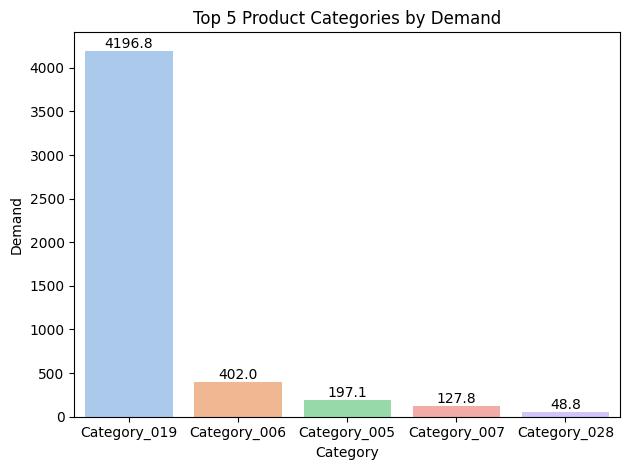

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 5 Product Categories by Total Demand
top_categories = (
    df_clean.groupby('Product_Category')['Order_Demand']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# Print Table
print("\n=== Top 5 Product Categories by Demand ===")
top_categories['Demand_M'] = top_categories['Order_Demand'] / 1_000_000
print(top_categories[['Product_Category', 'Demand_M']], "\n")

# Bar Chart
plt.figure()
sns.barplot(x="Product_Category", y="Demand_M", hue="Product_Category", data=top_categories, palette='pastel')
plt.title('Top 5 Product Categories by Demand')
plt.xlabel('Category')
plt.ylabel('Demand')

# Adding labels
for i, v in enumerate(top_categories['Demand_M']):
    plt.text(i, v, f"{v:.1f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

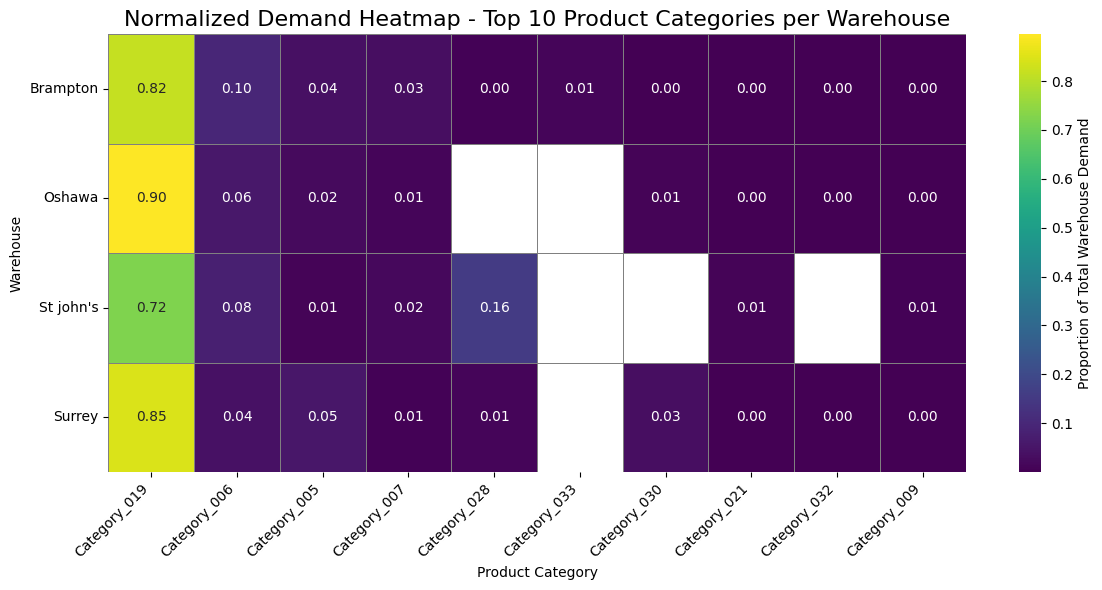

In [8]:
import numpy as np

# Identify top 10 categories by total demand
top_10_cat = df_clean.groupby('Product_Category')['Order_Demand'].sum().nlargest(10).index

# Pivot table for top categories only
pivot_top = df_clean.pivot_table(
    values='Order_Demand',
    index='Warehouse',
    columns='Product_Category',
    aggfunc='sum'
)[top_10_cat]

# Normalize by row (percentage per warehouse)
pivot_norm = pivot_top.div(pivot_top.sum(axis=1), axis=0)

# Plot normalized heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    pivot_norm,
    cmap='viridis',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Proportion of Total Warehouse Demand'}
)

plt.title("Normalized Demand Heatmap - Top 10 Product Categories per Warehouse", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Warehouse")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')

# Create Year-Month column
df['YearMonth'] = df['Date'].dt.to_period('M')

# Aggregate total monthly demand
monthly_demand = df.groupby('YearMonth')['Order_Demand'].sum()

# Convert to timestamp for better plotting/handling
monthly_demand.index = monthly_demand.index.to_timestamp()
pd.set_option('display.max_rows', None)
monthly_df = monthly_demand.reset_index()

In [10]:
# Top 5 Category Names
top_5_names = top_categories['Product_Category']

# Filter Original Data
df_top = df_clean[df_clean['Product_Category'].isin(top_5_names)].copy()

# Monthly Aggregation
df_top['YearMonth'] = df_top['Date'].dt.to_period('M')

monthly_demand = (
    df_top.groupby(['YearMonth', 'Product_Category'])['Order_Demand']
    .sum()
    .reset_index()
)
print(monthly_demand.sort_values(by='YearMonth').head())

# Convert for plotting
monthly_demand['YearMonth'] = monthly_demand['YearMonth'].dt.to_timestamp()

  YearMonth Product_Category  Order_Demand
0   2015-01     Category_005     2920345.0
1   2015-01     Category_006     6321967.0
2   2015-01     Category_007     2061395.0
3   2015-01     Category_019    61243661.0
4   2015-01     Category_028      508190.0


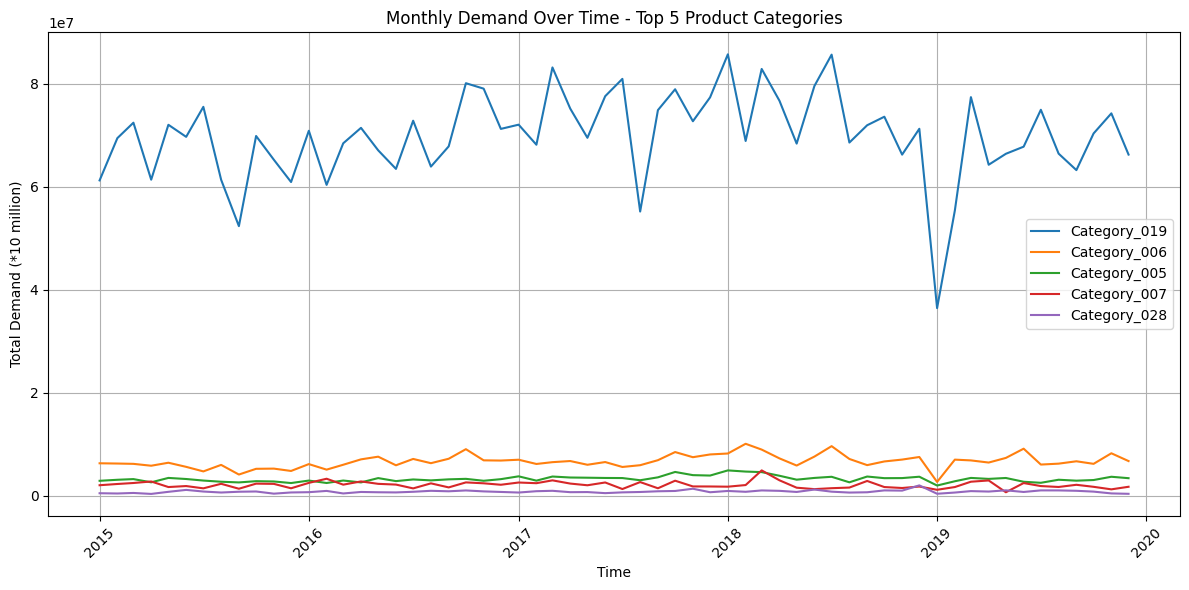

In [11]:
import matplotlib.ticker as ticker

# Line Chart
plt.figure(figsize=(12, 6))

for category in top_5_names:
    category_data = monthly_demand[monthly_demand['Product_Category'] == category]
    plt.plot(category_data['YearMonth'], category_data['Order_Demand'], label=category)

plt.title('Monthly Demand Over Time - Top 5 Product Categories')
plt.xlabel('Time')
plt.ylabel('Total Demand (*10 million)')
plt.legend()
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()

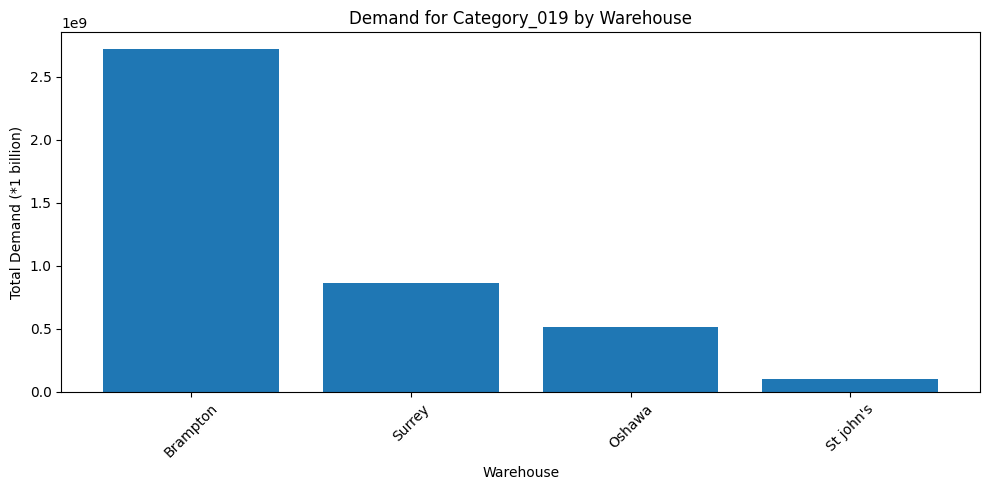

In [12]:
# Filter Category_019
df_cat19 = df_clean[df_clean['Product_Category'] == 'Category_019']

# Total Demand by Warehouse (or change grouping if needed)
cat19_demand = (
    df_cat19.groupby('Warehouse')['Order_Demand']
    .sum()
    .sort_values(ascending=False)
)

# Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(cat19_demand.index, cat19_demand.values)

plt.title('Demand for Category_019 by Warehouse')
plt.xlabel('Warehouse')
plt.ylabel('Total Demand (*1 billion)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

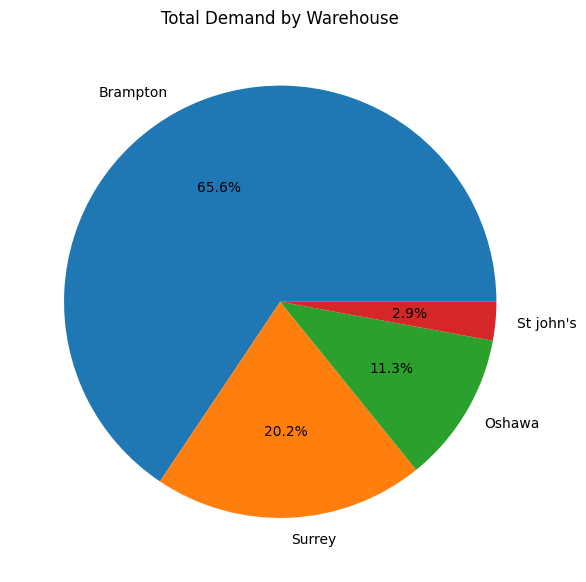

In [13]:
# Demand by Warehouse
warehouse_demand = (
    df_clean.groupby('Warehouse')['Order_Demand']
    .sum()
    .sort_values(ascending=False)
)

# Pie Chart
plt.figure(figsize=(6, 6))

plt.pie(
    warehouse_demand,
    labels=warehouse_demand.index,
    autopct='%1.1f%%'
)

plt.title('Total Demand by Warehouse')

plt.tight_layout()
plt.show()

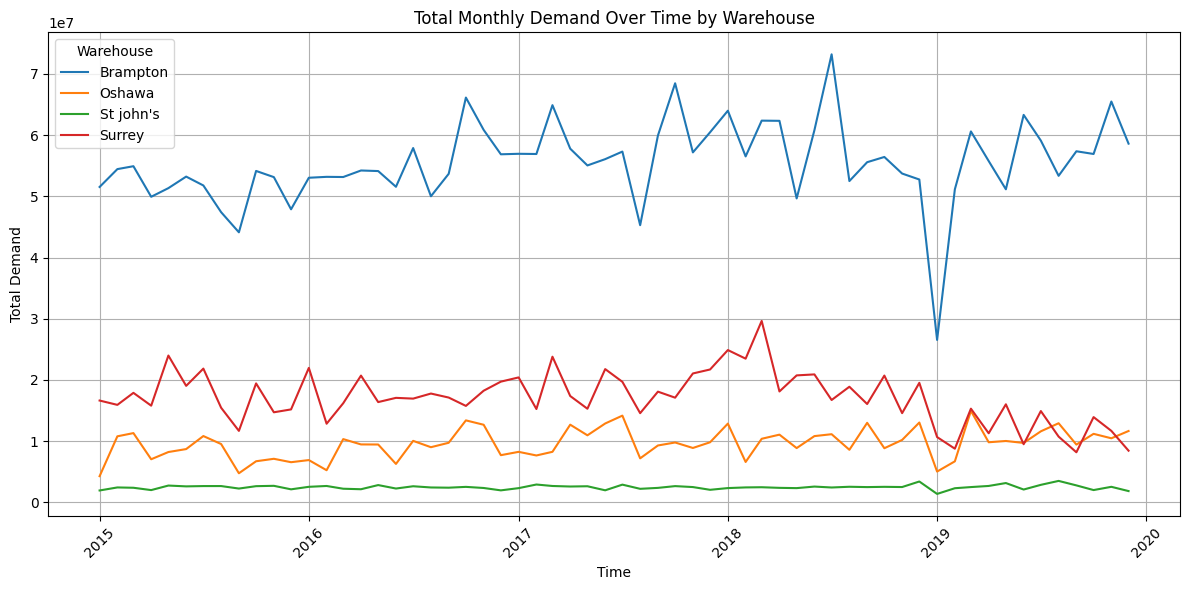

In [14]:
# Monthly Aggregation - Total Demand by Warehouse
df_clean['YearMonth'] = df_clean['Date'].dt.to_period('M')

warehouse_monthly = (
    df_clean.groupby(['YearMonth', 'Warehouse'])['Order_Demand']
    .sum()
    .reset_index()
)

# Convert for plotting
warehouse_monthly['YearMonth'] = warehouse_monthly['YearMonth'].dt.to_timestamp()

# Line Chart
plt.figure(figsize=(12, 6))

for warehouse in warehouse_monthly['Warehouse'].unique():
    data = warehouse_monthly[warehouse_monthly['Warehouse'] == warehouse]
    plt.plot(data['YearMonth'], data['Order_Demand'], label=warehouse)

plt.title('Total Monthly Demand Over Time by Warehouse')
plt.xlabel('Time')
plt.ylabel('Total Demand')
plt.legend(title='Warehouse')
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()


=== Top 5 Products - Brampton ===
Product_Code
Product_1359    468547000.0
Product_1248    287325000.0
Product_1295    121926300.0
Product_1286    100707300.0
Product_1274     91954000.0
Name: Order_Demand, dtype: float64


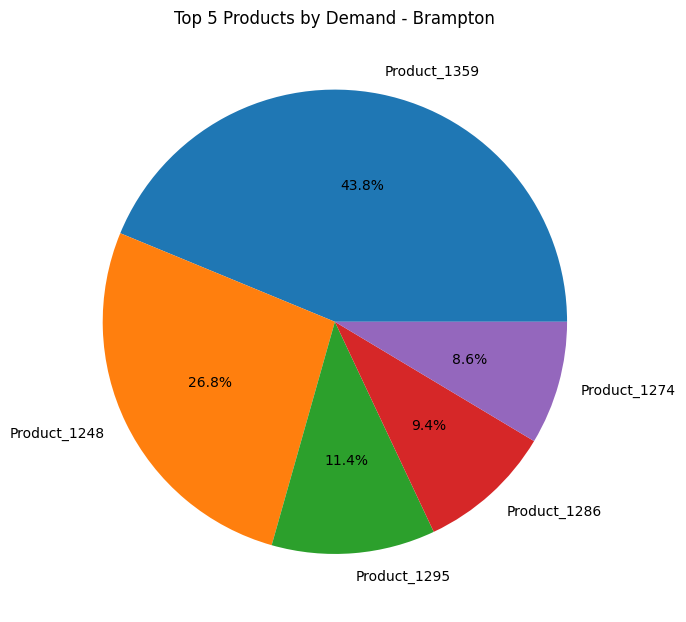


=== Top 5 Products - Oshawa ===
Product_Code
Product_1245    8.777800e+07
Product_1480    5.820000e+07
Product_1341    4.140600e+07
Product_1278    3.589400e+07
Product_1502    2.584246e+07
Name: Order_Demand, dtype: float64


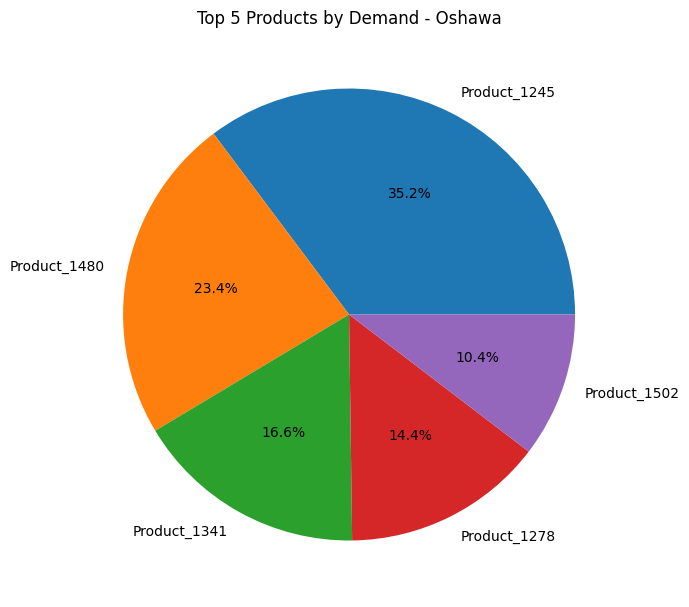


=== Top 5 Products - St john's ===
Product_Code
Product_1496    10420150.0
Product_1470     9279300.0
Product_1388     7646300.0
Product_0424     6127000.0
Product_1513     5913300.0
Name: Order_Demand, dtype: float64


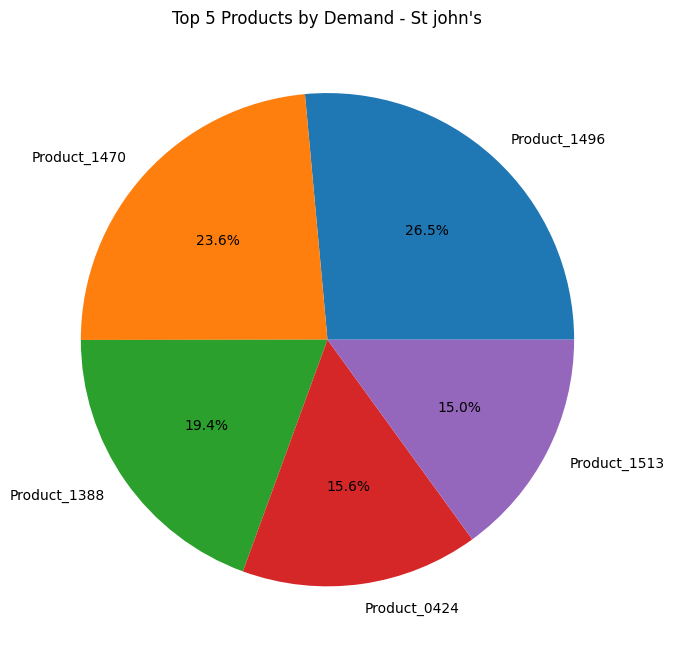


=== Top 5 Products - Surrey ===
Product_Code
Product_0083    1.823485e+08
Product_1341    1.247034e+08
Product_1432    5.306500e+07
Product_1574    4.420850e+07
Product_1342    4.369000e+07
Name: Order_Demand, dtype: float64


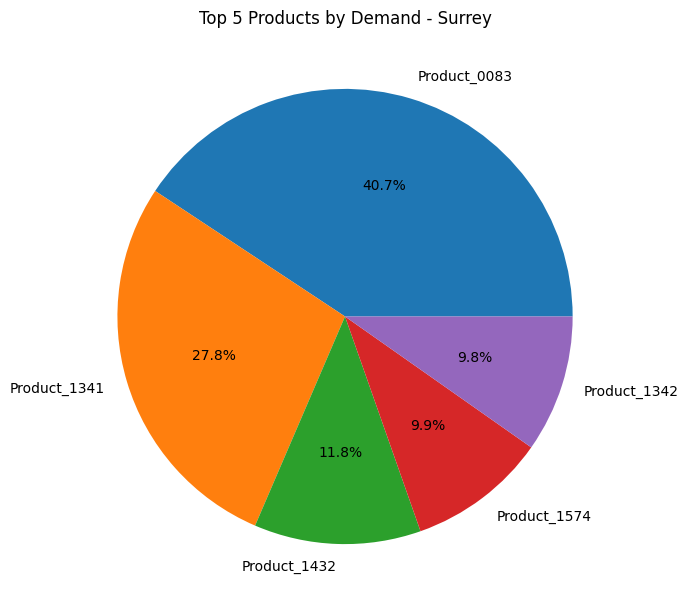

In [15]:
# Unique Warehouses
warehouses = sorted(df_clean['Warehouse'].dropna().unique())

# Pie Chart Per Warehouse - Top 5 Products
for warehouse in warehouses:
    
    # Top 5 Products in This Warehouse
    top_products = (
        df_clean[df_clean['Warehouse'] == warehouse]
        .groupby('Product_Code')['Order_Demand']
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )
    
    # Print Table
    print(f"\n=== Top 5 Products - {warehouse} ===")
    print(top_products)
    
    # Pie Chart
    plt.figure(figsize=(7, 7))
    
    plt.pie(
        top_products.values,
        labels=top_products.index,
        autopct='%1.1f%%'
    )
    
    plt.title(f'Top 5 Products by Demand - {warehouse}')
    
    plt.tight_layout()
    plt.show()


=== Brampton ===
  YearMonth  Order_Demand
0   2018-01    63997341.0
1   2018-02    56527880.0
2   2018-03    62375578.0
3   2018-04    62343896.0
4   2018-05    49656286.0
5   2018-06    60818058.0
6   2018-07    73217498.0
7   2018-08    52498610.0
8   2018-09    55581456.0
9   2018-10    56436328.0
   YearMonth  Order_Demand
14   2019-03    60611530.0
15   2019-04    55773351.0
16   2019-05    51152753.0
17   2019-06    63314904.0
18   2019-07    59111126.0
19   2019-08    53354175.0
20   2019-09    57368157.0
21   2019-10    56925432.0
22   2019-11    65499542.0
23   2019-12    58615448.0
YearMonth       period[M]
Order_Demand      float64
dtype: object

=== Oshawa ===
  YearMonth  Order_Demand
0   2017-12      873407.0
1   2018-01    12849950.0
2   2018-02     6578320.0
3   2018-03    10368696.0
4   2018-04    11044181.0
5   2018-05     8848928.0
6   2018-06    10807118.0
7   2018-07    11117094.0
8   2018-08     8568524.0
9   2018-09    12978666.0
   YearMonth  Order_Demand
14  

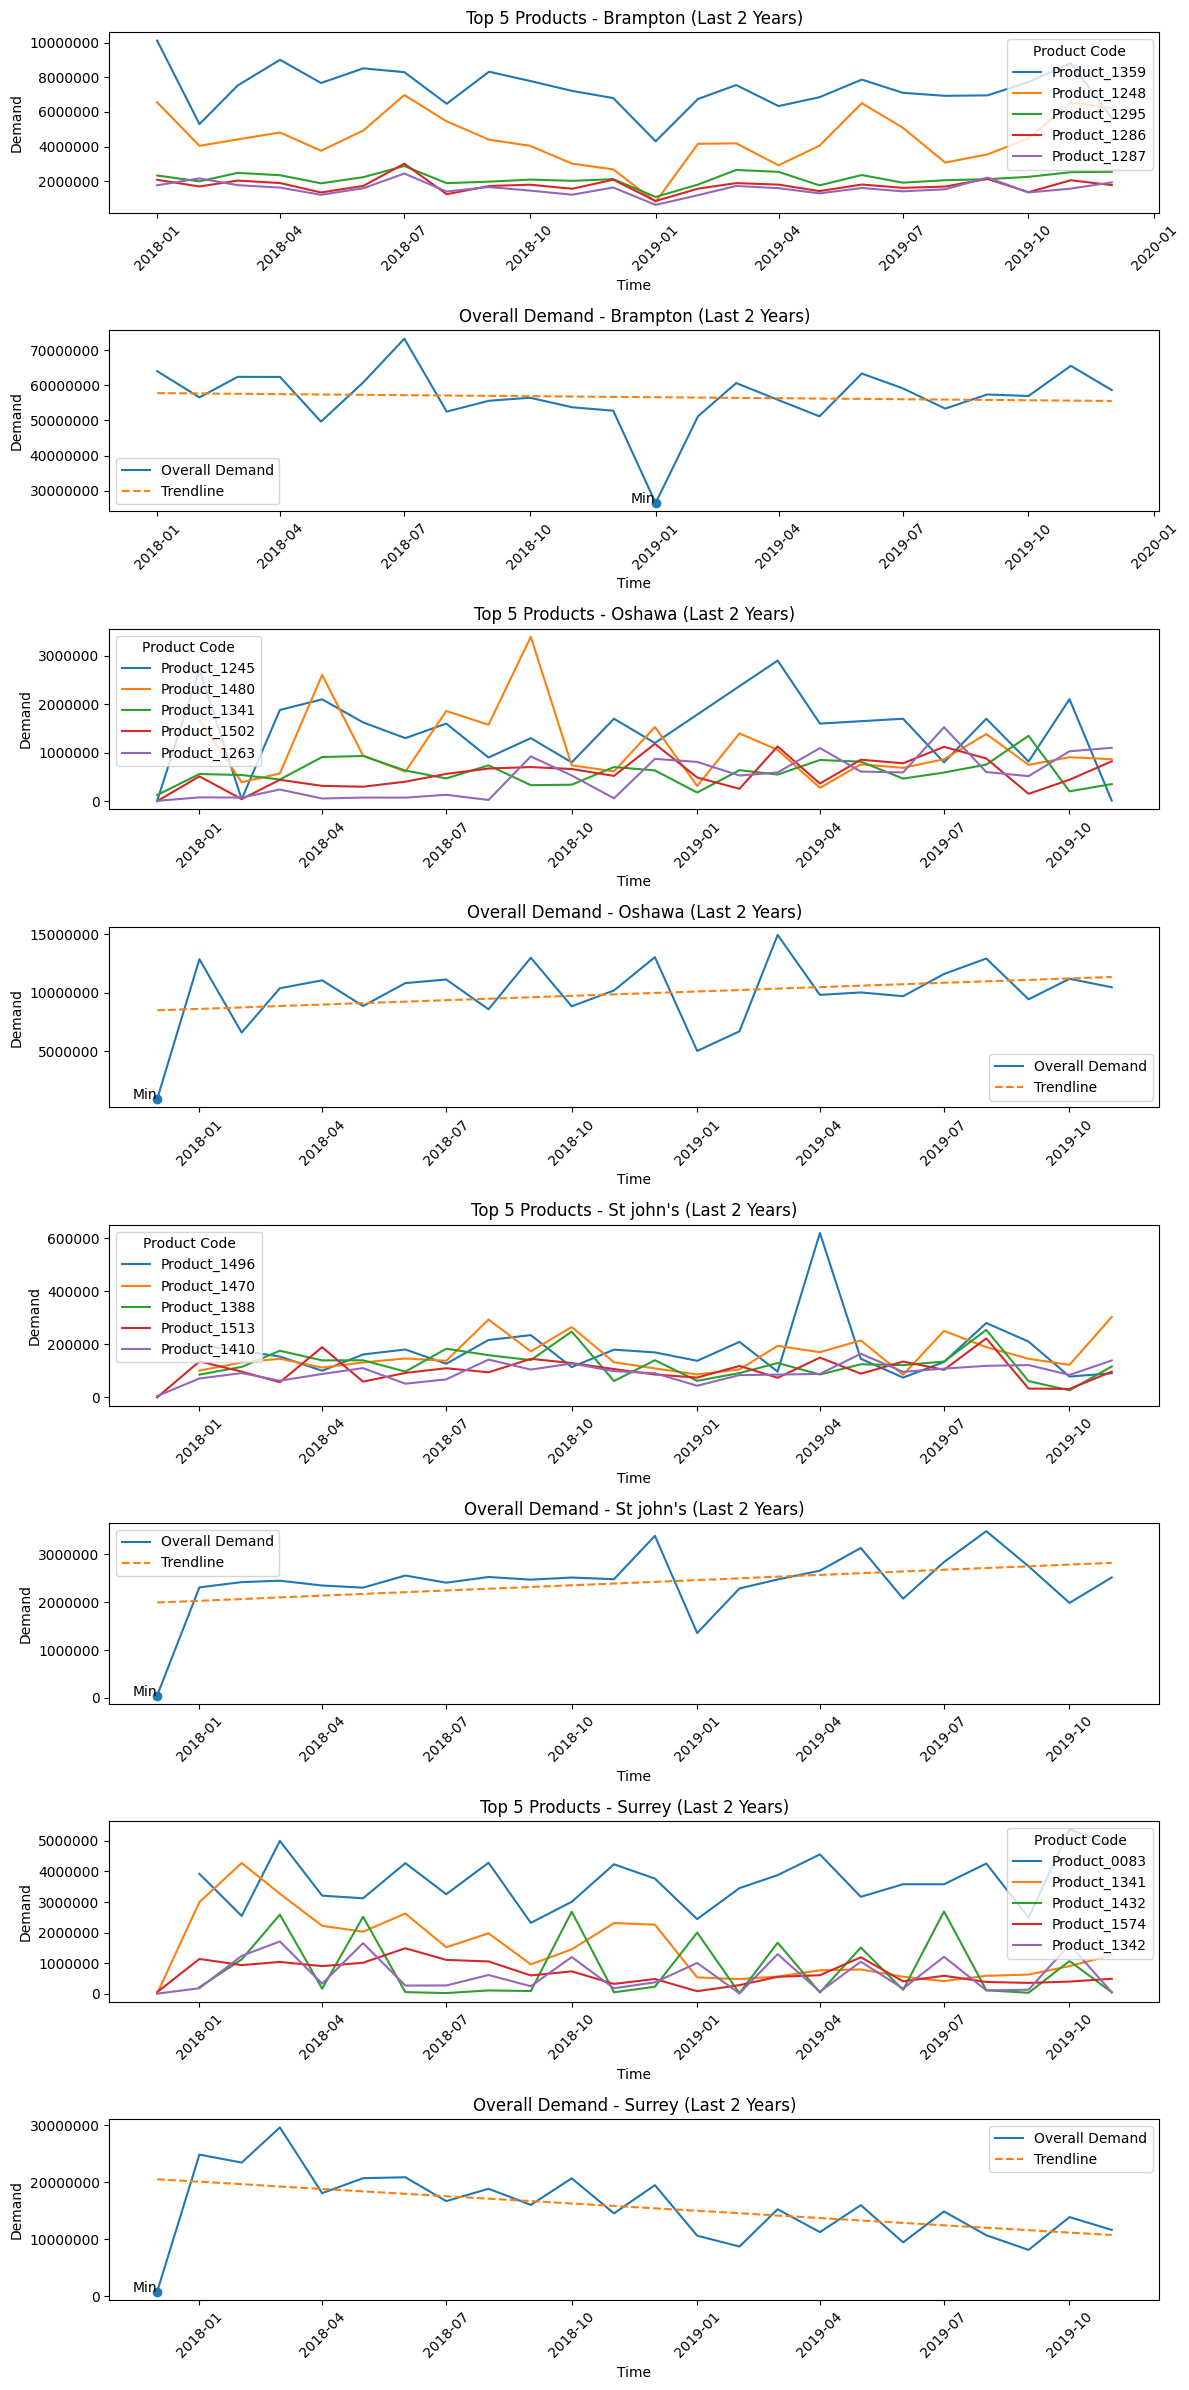

In [16]:
# Filter Last 2 Years
cutoff_date = df_clean['Date'].max() - pd.DateOffset(years=2)
df_recent = df_clean[df_clean['Date'] >= cutoff_date].copy()

# YearMonth
df_recent['YearMonth'] = df_recent['Date'].dt.to_period('M')

# Unique Warehouses
warehouses = sorted(df_recent['Warehouse'].dropna().unique())

# Create Subplots - 2 Per Warehouse
fig, axes = plt.subplots(len(warehouses) * 2, 1, figsize=(12, 6 * len(warehouses)))

# Handle Single Warehouse Case
if len(warehouses) == 1:
    axes = [axes[0], axes[1]]

# Loop Warehouses
for i, warehouse in enumerate(warehouses):
    
    ax_top = axes[i * 2]
    ax_bottom = axes[i * 2 + 1]
    
    # Warehouse Data
    df_wh = df_recent[df_recent['Warehouse'] == warehouse].copy()
    
    # Top 5 Products
    top_products = (
        df_wh.groupby('Product_Code')['Order_Demand']
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .index
    )
    
    # Top 5 Product Data
    df_top = df_wh[df_wh['Product_Code'].isin(top_products)].copy()
    
    # Monthly Aggregation - Top 5 Products
    monthly_products = (
        df_top.groupby(['YearMonth', 'Product_Code'])['Order_Demand']
        .sum()
        .reset_index()
    )
    # Remove Last Incomplete Month
    last_complete_month = df_clean['Date'].max().to_period('M') - 1
    df_recent = df_recent[df_recent['Date'].dt.to_period('M') <= last_complete_month].copy()
    
    monthly_products['YearMonth'] = monthly_products['YearMonth'].dt.to_timestamp()
    
    # Plot Top 5 Products
    for product in top_products:
        data = monthly_products[monthly_products['Product_Code'] == product].sort_values('YearMonth')
        ax_top.plot(data['YearMonth'], data['Order_Demand'], label=product)
    
    ax_top.set_title(f'Top 5 Products - {warehouse} (Last 2 Years)')
    ax_top.set_xlabel('Time')
    ax_top.set_ylabel('Demand')
    ax_top.legend(title='Product Code')
    ax_top.ticklabel_format(style='plain', axis='y')
    ax_top.tick_params(axis='x', rotation=45)
    
    # Monthly Aggregation - Overall Warehouse Demand
    monthly_total = (
        df_wh.groupby('YearMonth')['Order_Demand']
        .sum()
        .reset_index()
        .sort_values('YearMonth')
    )
#Monthly Total Check
    print(f"\n=== {warehouse} ===")
    print(monthly_total.head(10))
    print(monthly_total.tail(10))
    print(monthly_total.dtypes)
    
    monthly_total['YearMonth'] = monthly_total['YearMonth'].dt.to_timestamp()
    
    # Plot Overall Demand
    ax_bottom.plot(
        monthly_total['YearMonth'],
        monthly_total['Order_Demand'],
        label='Overall Demand'
    )
    
    # Trendline
    x = np.arange(len(monthly_total))
    y = monthly_total['Order_Demand'].values
    coeffs = np.polyfit(x, y, 1)
    trend = np.poly1d(coeffs)
    
    ax_bottom.plot(
        monthly_total['YearMonth'],
        trend(x),
        linestyle='--',
        label='Trendline'
    )
    ax_bottom.scatter(monthly_total.loc[monthly_total['Order_Demand'].idxmin(), 'YearMonth'],
                  monthly_total['Order_Demand'].min()); 
    ax_bottom.text(monthly_total.loc[monthly_total['Order_Demand'].idxmin(), 'YearMonth'],
               monthly_total['Order_Demand'].min(),
               'Min', ha='right')
    
    ax_bottom.set_title(f'Overall Demand - {warehouse} (Last 2 Years)')
    ax_bottom.set_xlabel('Time')
    ax_bottom.set_ylabel('Demand')
    ax_bottom.legend()
    ax_bottom.ticklabel_format(style='plain', axis='y')
    ax_bottom.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# **Time Series Forecasting**

## Preparing the data for Time Series
Steps:
- Aggregating demand values for better model prep
- Transformed the data by removing the anomoly month, january 2019, and imputing the average of february of 2019, and january of 2018
- Plotting the original series

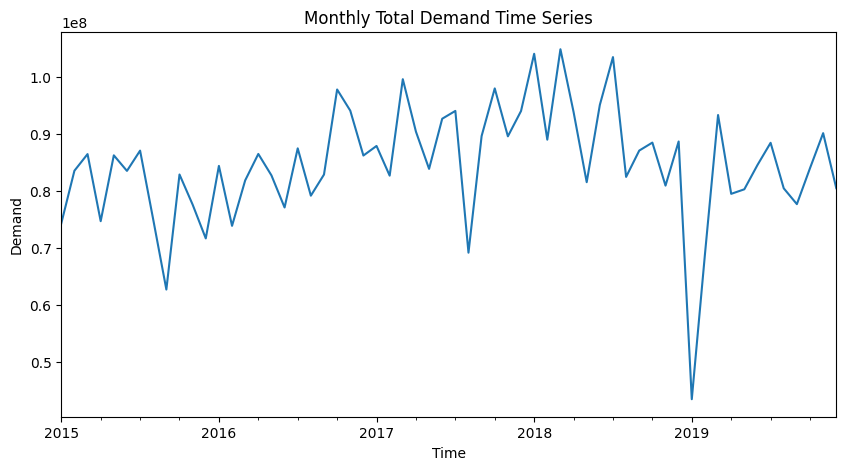

In [17]:
df_ts = df_clean.copy()
df_ts['YearMonth'] = df_ts['Date'].dt.to_period('M')

# Aggregate Demand
monthly_ts = df_ts.groupby('YearMonth')['Order_Demand'].sum()
monthly_ts.index = monthly_ts.index.to_timestamp()
monthly_ts = monthly_ts.asfreq('MS')

# Original
ts_original = monthly_ts.copy()

# Removed Jan 2019
ts_removed = monthly_ts.copy()
ts_removed = ts_removed.drop(pd.Timestamp('2019-01-01'), errors='ignore')

# Imputed Jan 2019 (neighbor-based)
ts_imputed = monthly_ts.copy()
if '2019-01-01' in ts_imputed.index:
    ts_imputed.loc['2019-01-01'] = (monthly_ts.loc['2018-12-01'] + monthly_ts.loc['2019-02-01']) / 2

# Plot original series
plt.figure(figsize=(10,5))
ts_original.plot()
plt.title('Monthly Total Demand Time Series')
plt.xlabel('Time')
plt.ylabel('Demand')
plt.show()

## Centered Moving Average
Steps:
- Creating the model
- Ploting the centered moving average on the original data

Findings:
- There is an upward trend from 2015-2018, then it downturns after

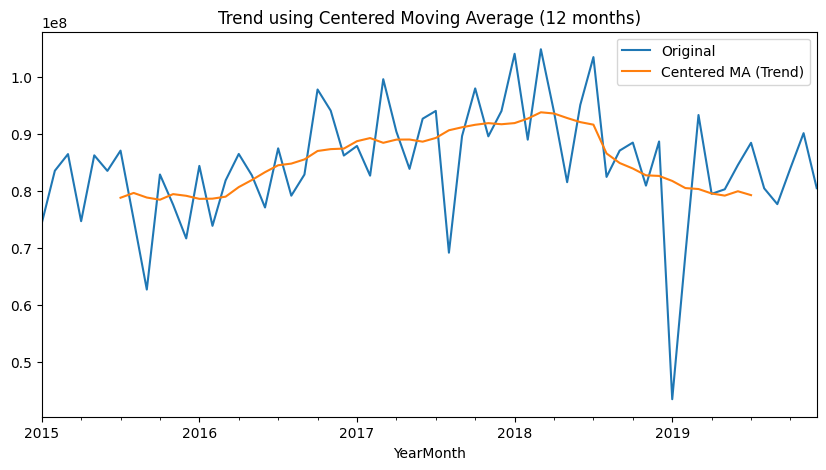

In [18]:
ma_centered = ts_original.rolling(12, center=True).mean()

plt.figure(figsize=(10,5))
ts_original.plot(label='Original')
ma_centered.plot(label='Centered MA (Trend)')
plt.legend()
plt.title('Trend using Centered Moving Average (12 months)')
plt.show()

## Train-Test Split
- Using a custom function to split the dataset into training and validation sets

In [19]:
# Partitioning the data
def train_valid_split(ts, train_ratio=0.8):
    n = int(len(ts) * train_ratio)
    train = ts.iloc[:n]
    valid = ts.iloc[n:]
    return train, valid

## 1. Moving Average

In [20]:
def moving_average(train_ts, valid_ts, window=12):
    ma = train_ts.rolling(window).mean().dropna()
    last_ma = ma.iloc[-1]
    return pd.Series(last_ma, index=valid_ts.index)

## 2. Simple Exponential Smoothing

In [21]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

def ses_forecast(train_ts, valid_ts):
    model = SimpleExpSmoothing(train_ts).fit(smoothing_level=0.2,
    optimized=False)
    return model.forecast(len(valid_ts))

## 3. Regression Forecasting

In [22]:
import statsmodels.formula.api as smf

def regression_forecast(train_ts, valid_ts):

    train_df = pd.DataFrame({'Demand': train_ts})
    train_df['trend'] = np.arange(1, len(train_df)+1)
    train_df['Month'] = train_df.index.month

    model = smf.ols(
        formula='Demand ~ trend + np.square(trend) + C(Month)',
        data=train_df
    ).fit()

    # Prepare validation data
    valid_df = pd.DataFrame({'Demand': valid_ts})
    valid_df['trend'] = np.arange(len(train_df)+1, len(train_df)+len(valid_df)+1)
    valid_df['Month'] = valid_df.index.month

    forecast = model.predict(valid_df)
    forecast.index = valid_ts.index

    return forecast

## 4. Naive Forecast

In [23]:
def naive_forecast(train_ts, valid_ts):
    last_val = train_ts.iloc[-1]
    return pd.Series(last_val, index=valid_ts.index)

## 5. Weighted Moving Average ( 3 and 6)

In [24]:
def weighted_moving_average(train_ts, valid_ts, window=3):
    weights = np.arange(1, window + 1)

    wma_values = []
    for i in range(len(train_ts) - window + 1):
        subset = train_ts.iloc[i:i+window]
        wma_values.append(np.dot(subset, weights) / weights.sum())

    last_wma = wma_values[-1]
    return pd.Series(last_wma, index=valid_ts.index)

## Final Comparison of all the Models accross three situations

### Performance Comparison Metrics
- Calculating root mean squared error, mean absolute error and mean absolute percentage error across models to compare model performances

In [25]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

def prepare_actual_pred(actual, pred):
    df = pd.concat([actual, pred], axis=1).dropna()
    df.columns = ["actual", "pred"]
    return df

def rmse(actual, pred):
    df = prepare_actual_pred(actual, pred)
    return np.sqrt(((df["actual"] - df["pred"])**2).mean())

def mae(actual, pred):
    df = prepare_actual_pred(actual, pred)
    return np.abs(df["actual"] - df["pred"]).mean()

def mape(actual, pred):
    df = prepare_actual_pred(actual, pred)
    return np.mean(np.abs((df["actual"] - df["pred"]) / df["actual"])) * 100

### Function for Running All Models 
- Defining a function for running all models at the same time and writing the results to a dictionary to be called later
- defining a function to gather the error results into a list called metrics
- Printing results

In [26]:
def run_all_models(ts):
    
    train_ts, valid_ts = train_valid_split(ts)

    results = {
        'Naive': naive_forecast(train_ts, valid_ts),
        'MA': moving_average(train_ts, valid_ts),
        'WMA_3': weighted_moving_average(train_ts, valid_ts, 3),
        'WMA_6': weighted_moving_average(train_ts, valid_ts, 6),
        'SES': ses_forecast(train_ts, valid_ts),
        'Regression': regression_forecast(train_ts, valid_ts)
    }

    return train_ts, valid_ts, results

def evaluate_models(ts, label="Dataset", sort_by="RMSE"):
    
    train_ts, valid_ts, results = run_all_models(ts)

    metrics = []

    for name, pred in results.items():
        metrics.append({
            "Model": name,
            "RMSE": rmse(valid_ts, pred),
            "MAE": mae(valid_ts, pred),
            "MAPE": mape(valid_ts, pred)
        })

    metrics_df = pd.DataFrame(metrics)

    # Sort by best model
    metrics_df = metrics_df.sort_values(by=sort_by).reset_index(drop=True)

    print(f"\n=== {label} Model Performance ===")
    print(metrics_df)

    best_model = metrics_df.iloc[0]
    print(f"\n Best Model ({sort_by}): {best_model['Model']}")

    return train_ts, valid_ts, results, metrics_df

## Running and Plotting the performance of all the Models 
Steps:
- Defining a function to convert metrics to numeric and plotting them as a bar chart
- calling the metrics function to view error results across models - and comparing the data without removing the anomoly to the removed anomoly, and imputed data.

Findings:
- Plotting results in a bar chart to visualize
- When the anomoly month is removed and imputed, error results improve significantly - The percentage error range for the data with anomoly was 15-20%, whereas it was 8-12% with imputed anomoly.
- The best performing model on the original data was the 3-weighted moving average, and the worst was Regression
- on the anomoly removed data, 3-weighted moving average is also the best performing, moving average being the worst.

In [27]:
def plot_model_metrics(metrics_df, title="Model Performance Comparison"):
    metrics_df = metrics_df.set_index("Model")
    
    # Convert to numeric
    for col in ["RMSE", "MAE"]:
        metrics_df[col] = pd.to_numeric(metrics_df[col])
    
    metrics_to_plot = ["RMSE", "MAE"]
    
    metrics_df[metrics_to_plot].plot(kind='bar', figsize=(10,6))
    
    plt.title(title)
    plt.ylabel("Error")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


=== Original Model Performance ===
        Model          RMSE           MAE       MAPE
0       WMA_3  1.412297e+07  9.068862e+06  15.157509
1       WMA_6  1.442921e+07  9.376848e+06  15.623842
2       Naive  1.554744e+07  1.041353e+07  17.178414
3         SES  1.556997e+07  1.043835e+07  17.213611
4          MA  1.748276e+07  1.262172e+07  20.233670
5  Regression  1.796727e+07  1.243604e+07  20.138915

 Best Model (RMSE): WMA_3


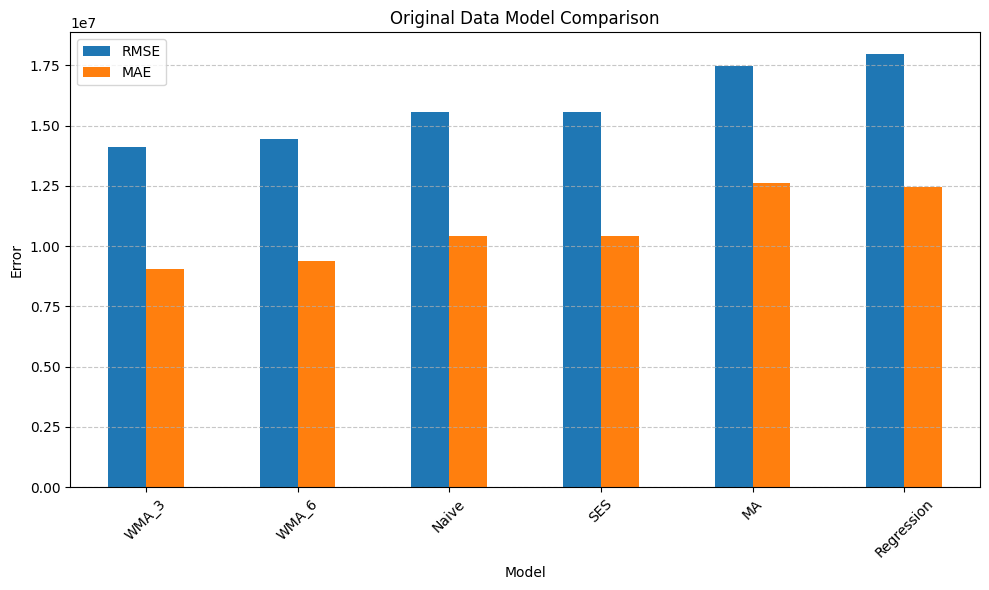

In [28]:
train_o, valid_o, res_o, metrics_o = evaluate_models(ts_original, "Original")
plot_model_metrics(metrics_o, "Original Data Model Comparison")


=== Removed Model Performance ===
        Model          RMSE           MAE       MAPE
0       WMA_3  6.499882e+06  5.226098e+06   6.530598
1       Naive  6.674875e+06  5.146591e+06   6.166730
2       WMA_6  7.443762e+06  6.034482e+06   7.677482
3         SES  8.540515e+06  6.543323e+06   8.431382
4  Regression  1.004132e+07  8.329902e+06  10.460994
5          MA  1.102687e+07  9.230491e+06  11.768122

 Best Model (RMSE): WMA_3


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


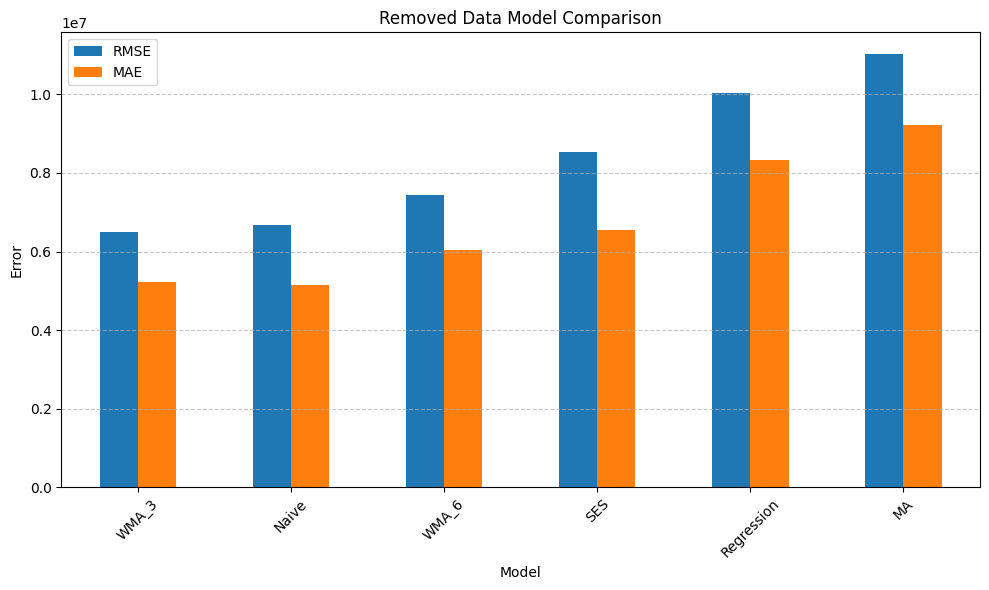

In [29]:
train_r, valid_r, res_r, metrics_r = evaluate_models(ts_removed, "Removed")
plot_model_metrics(metrics_r, "Removed Data Model Comparison")


=== Imputed Model Performance ===
        Model          RMSE           MAE       MAPE
0       WMA_3  7.294367e+06  6.132949e+06   7.790837
1       WMA_6  7.637722e+06  6.440936e+06   8.204447
2       Naive  8.952296e+06  7.477616e+06   9.588294
3         SES  8.979212e+06  7.502432e+06   9.620305
4  Regression  1.098908e+07  9.500132e+06  11.958663
5          MA  1.126067e+07  9.685803e+06  12.391881

 Best Model (RMSE): WMA_3


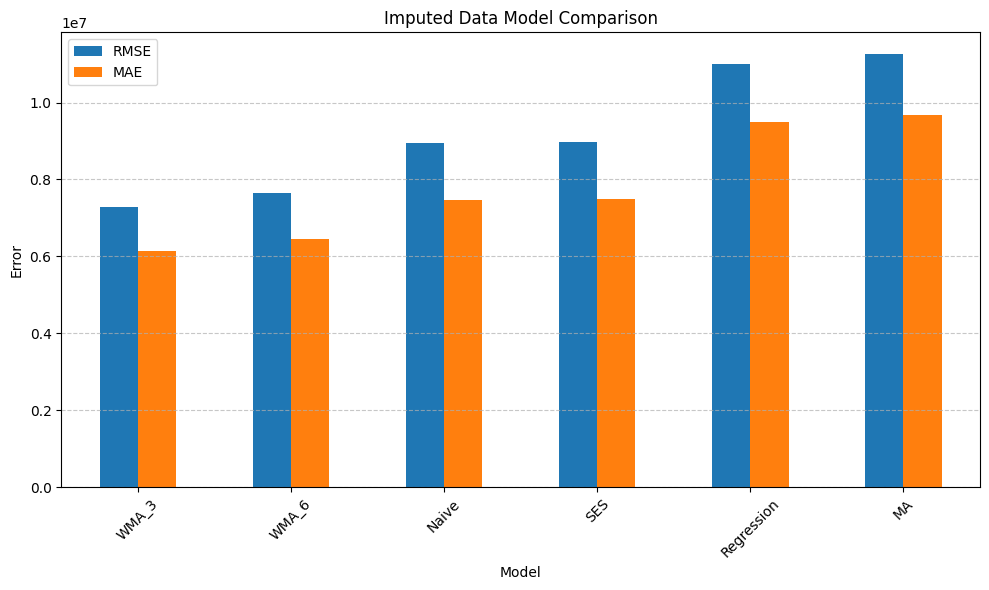

In [30]:
train_i, valid_i, res_i, metrics_i = evaluate_models(ts_imputed, "Imputed")
plot_model_metrics(metrics_i, "Imputed Data Model Comparison")

### Forecasting and Plotting using our 6 Models
Steps:
- Defining a function to forecast and plot the results
- Plotting a line chart for original data, removed, and imputed, including the visualization of results from all models
- Printing the best results by dataset and model type

Findings:
- Best model overall was WMA-3 on the removed dataset. Best for RSME was WMA-3, MAE and MAPE best was naive.
- Best condition appears to be the removed dataset

In [31]:
def plot_forecasts(train_ts, valid_ts, results, title):
    plt.figure(figsize=(12,6))
    
    # Plot actuals
    full_series = pd.concat([train_ts, valid_ts])
    full_series = full_series.asfreq('MS')
    plt.plot(full_series.index, full_series.values, color='black', label='Actual')
    
    for name, forecast in results.items():
        # If forecast is scalar repeated, make it a Series
        if isinstance(forecast, (int, float, np.float64, np.int64)):
            forecast = pd.Series([forecast]*len(valid_ts), index=valid_ts.index)
        
        # If forecast is numpy array, convert to Series
        elif isinstance(forecast, np.ndarray):
            forecast = pd.Series(forecast, index=valid_ts.index)
        
        # If forecast is Series but index mismatched, fix index
        elif isinstance(forecast, pd.Series):
            if not forecast.index.equals(valid_ts.index):
                forecast = pd.Series(forecast.values, index=valid_ts.index)
        
        plt.plot(valid_ts.index, forecast.values, linestyle='--', label=name)
    
    plt.axvline(x=valid_ts.index[0], color='gray', linestyle=':', label='Forecast Start')
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.legend()
    plt.show()

In [32]:
def plot_forecasts(train_ts, valid_ts, results, title):
    plt.figure(figsize=(12,6))
    
    # Plot actuals
    full_series = pd.concat([train_ts, valid_ts])
    full_series = full_series.asfreq('MS')
    plt.plot(full_series.index, full_series.values, color='black', label='Actual')
    
    for name, forecast in results.items():
        # If forecast is scalar repeated, make it a Series
        if isinstance(forecast, (int, float, np.float64, np.int64)):
            forecast = pd.Series([forecast]*len(valid_ts), index=valid_ts.index)
        
        # If forecast is numpy array, convert to Series
        elif isinstance(forecast, np.ndarray):
            forecast = pd.Series(forecast, index=valid_ts.index)
        
        # If forecast is Series but index mismatched, fix index
        elif isinstance(forecast, pd.Series):
            if not forecast.index.equals(valid_ts.index):
                forecast = pd.Series(forecast.values, index=valid_ts.index)
        
        plt.plot(valid_ts.index, forecast.values, linestyle='--', label=name)
    
    plt.axvline(x=valid_ts.index[0], color='gray', linestyle=':', label='Forecast Start')
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.legend()
    plt.show()

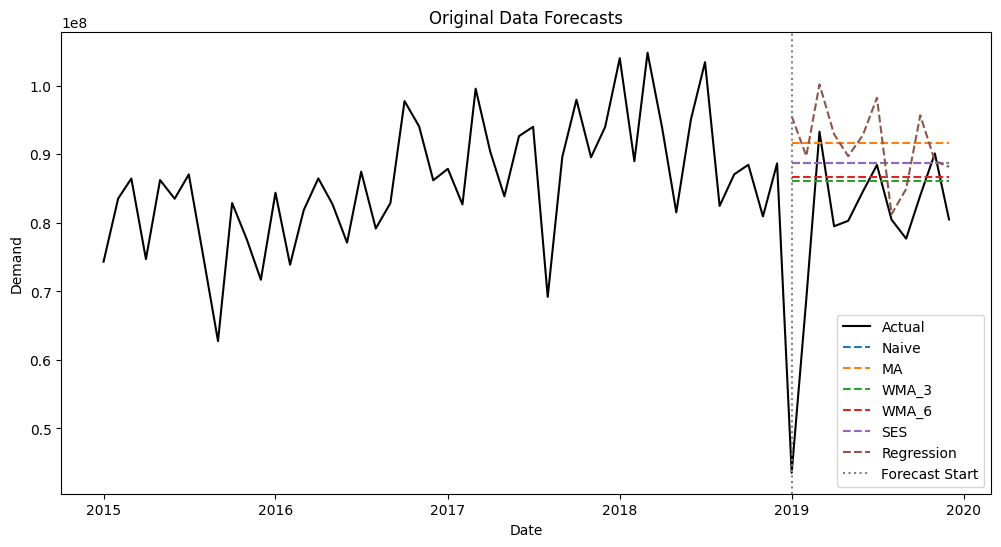

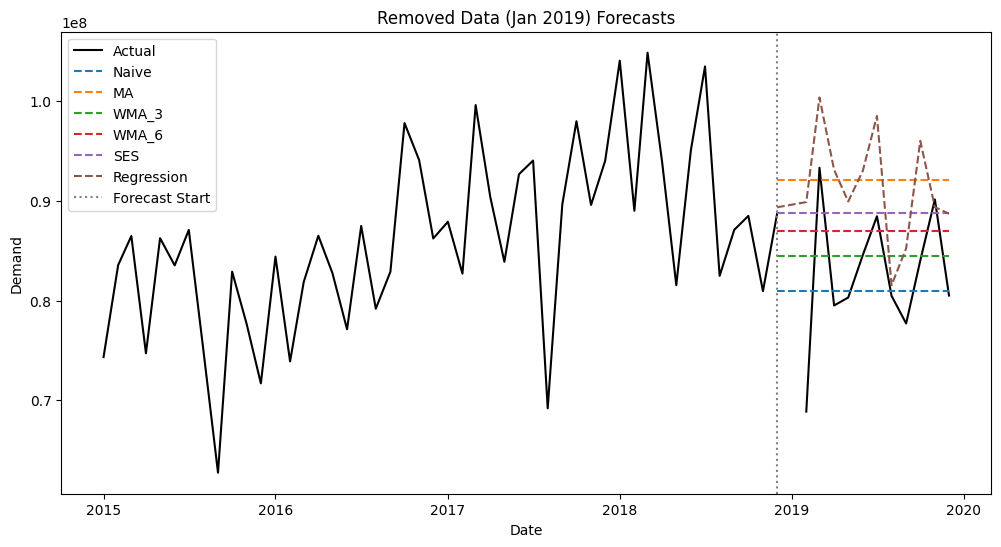

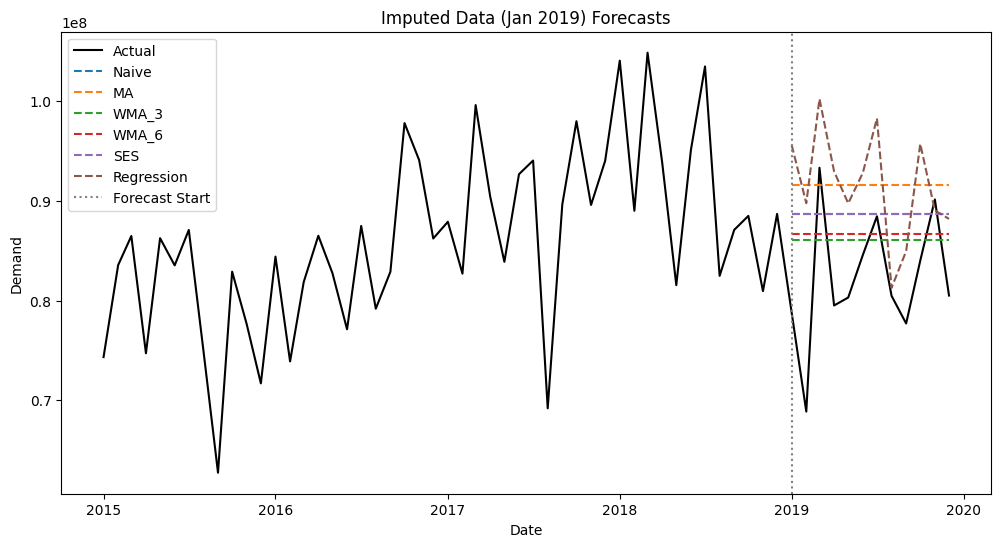

In [33]:
# For Original Data
plot_forecasts(train_o, valid_o, res_o, "Original Data Forecasts")
# For Removed Jan 2019
plot_forecasts(train_r, valid_r, res_r, "Removed Data (Jan 2019) Forecasts")
# For Imputed Jan 2019
plot_forecasts(train_i, valid_i, res_i, "Imputed Data (Jan 2019) Forecasts")

### Determining the Overall Best Model and Condition 

In [34]:
metrics_o['Condition'] = 'Original'
metrics_r['Condition'] = 'Removed'
metrics_i['Condition'] = 'Imputed'

all_metrics = pd.concat([metrics_o, metrics_r, metrics_i], ignore_index=True)

best_row = all_metrics.loc[all_metrics['RMSE'].idxmin()]
print("Best Model Overall:")
print(best_row)

Best Model Overall:
Model                 WMA_3
RMSE         6499882.243148
MAE          5226097.916667
MAPE               6.530598
Condition           Removed
Name: 6, dtype: object


In [35]:
best_rmse = all_metrics.loc[all_metrics['RMSE'].idxmin()]
best_mae = all_metrics.loc[all_metrics['MAE'].idxmin()]
best_mape = all_metrics.loc[all_metrics['MAPE'].idxmin()]

print("Best by RMSE:", best_rmse)
print("Best by MAE:", best_mae)
print("Best by MAPE:", best_mape)

Best by RMSE: Model                 WMA_3
RMSE         6499882.243148
MAE          5226097.916667
MAPE               6.530598
Condition           Removed
Name: 6, dtype: object
Best by MAE: Model                 Naive
RMSE         6674874.654476
MAE              5146590.75
MAPE                6.16673
Condition           Removed
Name: 7, dtype: object
Best by MAPE: Model                 Naive
RMSE         6674874.654476
MAE              5146590.75
MAPE                6.16673
Condition           Removed
Name: 7, dtype: object


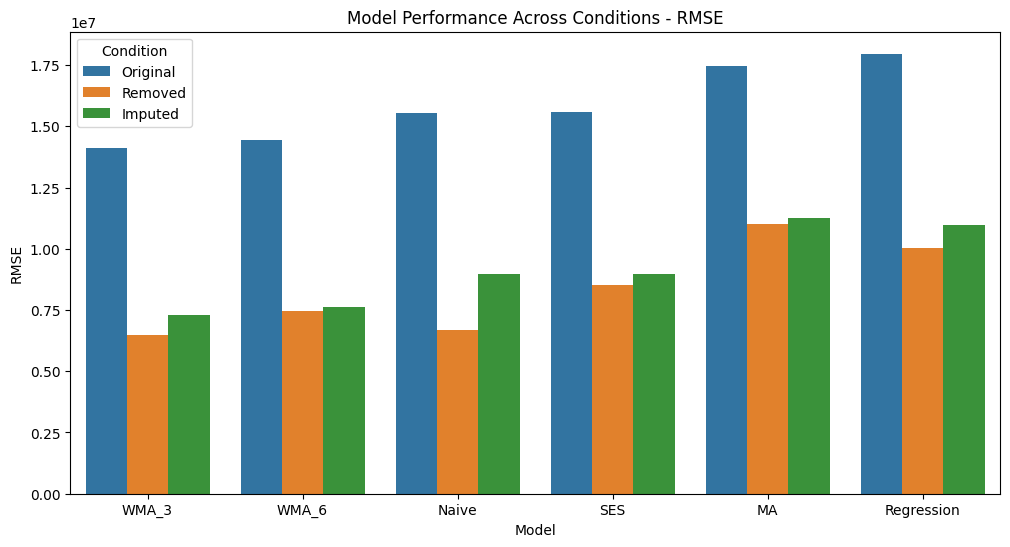

In [36]:
plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='RMSE', hue='Condition', data=all_metrics)
plt.title("Model Performance Across Conditions - RMSE")
plt.show()

### Forecasting the Overall Demand for Brampton Warehouse (using the best overall model and condition)
- Applying the same modelling techniques to Brampton warehouse entries, using the WMA-3 model.

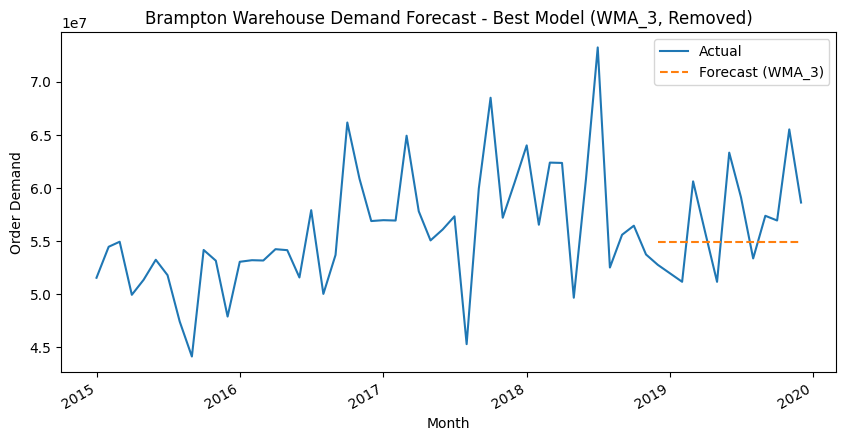

In [37]:
# 🔹 Filter Brampton warehouse using "Removed" dataset
df_brampton = df_clean[df_clean["Warehouse"] == "Brampton"].copy()
df_brampton['YearMonth'] = df_brampton['Date'].dt.to_period('M')

# Aggregate monthly demand
brampton_ts = df_brampton.groupby('YearMonth')['Order_Demand'].sum()
brampton_ts.index = brampton_ts.index.to_timestamp()

# Remove Jan 2019 to match "Removed" condition
brampton_ts = brampton_ts.drop(pd.Timestamp('2019-01-01'), errors='ignore')

# Split train and validation
train_b, valid_b = train_valid_split(brampton_ts)

# Apply Best Model (WMA_3)
forecast_b = weighted_moving_average(train_b, valid_b, window=3)

# Plot
plt.figure(figsize=(10,5))
brampton_ts.plot(label='Actual')
forecast_b.plot(label='Forecast (WMA_3)', linestyle='--')
plt.title("Brampton Warehouse Demand Forecast - Best Model (WMA_3, Removed)")
plt.xlabel("Month")
plt.ylabel("Order Demand")
plt.legend()
plt.show()

### Forecasting the Demand for **"Product 1359"** in Brampton Warehouse (using the best overall model and condition)
- Using the same modelling techniques with the WMA-3 model and removed condition to look at highest demand product in Brampton

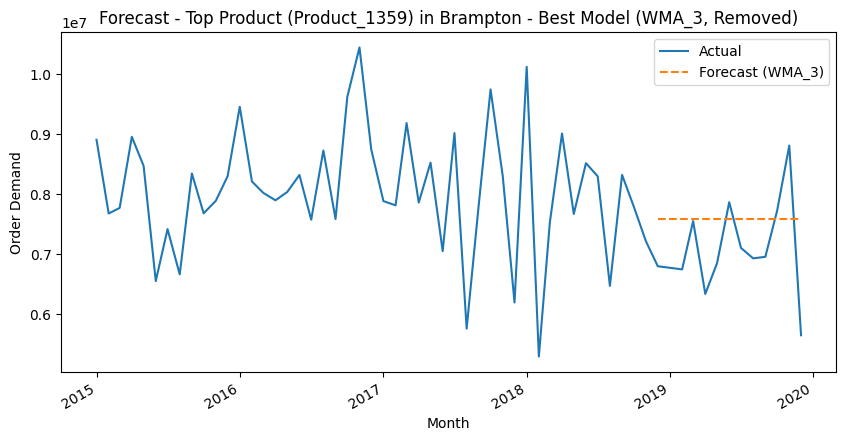

In [38]:
top_product = "Product_1359"

df_top_prod = df_clean[
    (df_clean["Warehouse"] == "Brampton") &
    (df_clean["Product_Code"] == top_product)
].copy()

df_top_prod['YearMonth'] = df_top_prod['Date'].dt.to_period('M')

# Aggregate monthly demand
prod_ts = df_top_prod.groupby('YearMonth')['Order_Demand'].sum()
prod_ts.index = prod_ts.index.to_timestamp()

# Remove Jan 2019 to match "Removed" condition
prod_ts = prod_ts.drop(pd.Timestamp('2019-01-01'), errors='ignore')

# Train-test split
train_p, valid_p = train_valid_split(prod_ts)

# Apply Best Model (WMA_3)
forecast_p = weighted_moving_average(train_p, valid_p, window=3)

# Plot
plt.figure(figsize=(10,5))
prod_ts.plot(label='Actual')
forecast_p.plot(label='Forecast (WMA_3)', linestyle='--')
plt.title("Forecast - Top Product (Product_1359) in Brampton - Best Model (WMA_3, Removed)")
plt.xlabel("Month")
plt.ylabel("Order Demand")
plt.legend()
plt.show()

## Final Thoughts:
- Using this forecasting model, the company can more accurately predict demand for each of their warehouses so they will be able to keep up with supply and run a smoother logistical operation
- The model would likely be applied to specific warehouses, since they will each have their own seperate demand issues. It can be applied to specific products, since as adressed previously, demand by product seems to vary drastically and changes over time, making it a key factor to predict for the company to successfully keep up with demand.

# **Comparison with Advanced or AI-Based Methods**

## NEW MODEL 1 — ARIMA 

In [39]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

def arima_forecast(train_ts, valid_ts, order=(1,1,1)):
    model = ARIMA(train_ts, order=order)
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=len(valid_ts))
    forecast.index = valid_ts.index
    return forecast

# Run ARIMA
train_ts, valid_ts = train_valid_split(ts_removed)
arima_pred = arima_forecast(train_ts, valid_ts)

# Evaluate
print("ARIMA Performance:")
print("RMSE:", rmse(valid_ts, arima_pred))
print("MAE:", mae(valid_ts, arima_pred))
print("MAPE:", mape(valid_ts, arima_pred))

ARIMA Performance:
RMSE: 6397381.754815699
MAE: 5205034.588516322
MAPE: 6.438696150074606


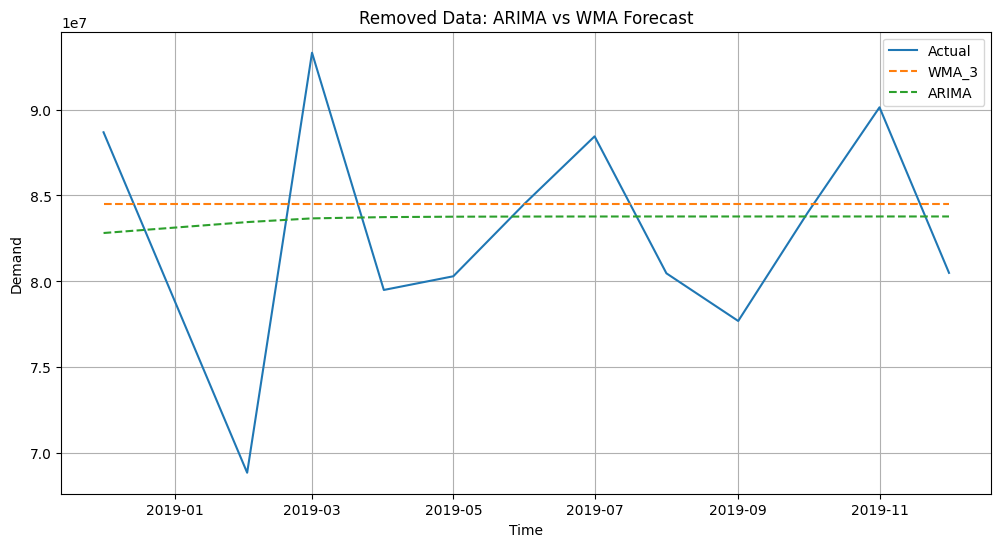

In [40]:
# Plotting the forecast comparison
plt.figure(figsize=(12,6))

# Actual
plt.plot(valid_ts.index, valid_ts.values, label="Actual")

# WMA (best from your results)
wma_pred = weighted_moving_average(train_ts, valid_ts, 3)
plt.plot(valid_ts.index, wma_pred, linestyle='--', label="WMA_3")

# ARIMA
plt.plot(valid_ts.index, arima_pred, linestyle='--', label="ARIMA")

plt.title("Removed Data: ARIMA vs WMA Forecast")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.grid()
plt.show()

### Error Distribution Comparison for ARIMA and WMA 3

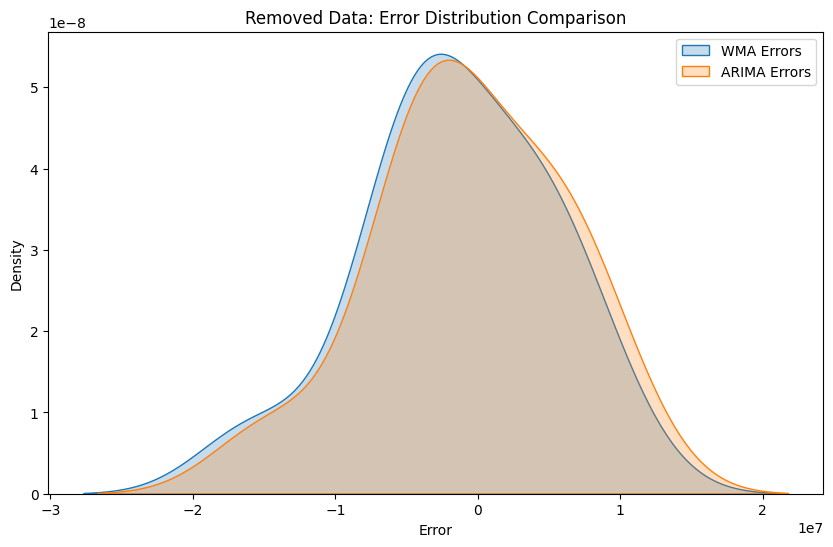

In [41]:
# Errors
error_wma = valid_ts - wma_pred
error_arima = valid_ts - arima_pred

plt.figure(figsize=(10,6))

sns.kdeplot(error_wma, label='WMA Errors', fill=True)
sns.kdeplot(error_arima, label='ARIMA Errors', fill=True)

plt.title("Removed Data: Error Distribution Comparison")
plt.xlabel("Error")
plt.legend()
plt.show()

### Residual Analysis for ARIMA

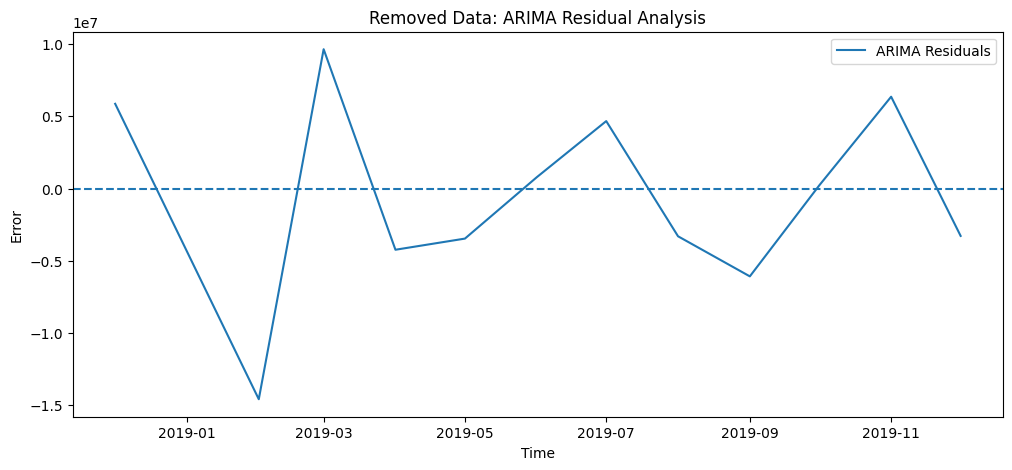

In [42]:
plt.figure(figsize=(12,5))

plt.plot(valid_ts.index, error_arima, label='ARIMA Residuals')
plt.axhline(0, linestyle='--')

plt.title("Removed Data: ARIMA Residual Analysis")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.show()

## NEW MODEL 2 — XGBoost (AI / ML Model)

### Feature Engineering

In [46]:
!pip install xgboost
from xgboost import XGBRegressor

# FEATURE ENGINEERING FOR ML
df_ml = ts_removed.reset_index()
df_ml.columns = ['Date', 'Demand']

df_ml['Month'] = df_ml['Date'].dt.month
df_ml['Year'] = df_ml['Date'].dt.year

# Lag Features
df_ml['lag1'] = df_ml['Demand'].shift(1)
df_ml['lag2'] = df_ml['Demand'].shift(2)
df_ml['lag3'] = df_ml['Demand'].shift(3)

df_ml = df_ml.dropna()

# Train-test split
split = int(len(df_ml)*0.8)

train_ml = df_ml.iloc[:split]
valid_ml = df_ml.iloc[split:]

X_train = train_ml[['Month','Year','lag1','lag2','lag3']]
y_train = train_ml['Demand']

X_valid = valid_ml[['Month','Year','lag1','lag2','lag3']]
y_valid = valid_ml['Demand']

# Training Model
model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4
)

model_xgb.fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_valid)
xgb_pred = pd.Series(xgb_pred, index=y_valid.index)

# Evaluation
print("XGBoost (Removed Data) Performance:")
print("RMSE:", rmse(y_valid, xgb_pred))
print("MAE:", mae(y_valid, xgb_pred))
print("MAPE:", mape(y_valid, xgb_pred))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 7.2 MB/s eta 0:00:00a 0:00:01
XGBoost (Removed Data) Performance:
RMSE: 10105242.648402615
MAE: 7672370.916666667
MAPE: 9.619369130778987


In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_valid.index, y_valid.values, label="Actual")
plt.plot(y_valid.index, xgb_pred, linestyle='--', label="XGBoost")

plt.title("Removed Data: XGBoost Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.grid()
plt.show()

### Feature Importance Mapping

In [ ]:
# FEATURE IMPORTANCE (XGBOOST)
importance = model_xgb.feature_importances_
features = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)

plt.title("XGBoost Feature Importance (Removed Data)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

### Actual vs Predicted Scatter Plot

In [ ]:
# ACTUAL VS PREDICTED
plt.figure(figsize=(8,8))

plt.scatter(y_valid, xgb_pred)
plt.plot([y_valid.min(), y_valid.max()],
         [y_valid.min(), y_valid.max()],
         linestyle='--')  # perfect prediction line

plt.title("XGBoost: Actual vs Predicted (Removed Data)")
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")

plt.grid()
plt.show()

### Residual Plot (ML Diagnostics)

In [ ]:
# RESIDUAL PLOT
residuals_xgb = y_valid - xgb_pred

plt.figure(figsize=(12,5))

plt.scatter(y_valid.index, residuals_xgb)
plt.axhline(0, linestyle='--')

plt.title("XGBoost Residuals Over Time (Removed Data)")
plt.xlabel("Time")
plt.ylabel("Residuals")

plt.grid()
plt.show()

## FINAL COMPARISON
- When comparing the WMA-3 model with ARIMA and XGBoost, ARIMA performed the best overall with 6.4% error, followed closely by WMA-3 at 6.5% error

### Table

In [ ]:
comparison_removed = pd.DataFrame({
    "Model": ["WMA_3", "ARIMA", "XGBoost"],
    "RMSE": [
        rmse(valid_ts, wma_pred),
        rmse(valid_ts, arima_pred),
        rmse(y_valid, xgb_pred)
    ],
    "MAE": [
        mae(valid_ts, wma_pred),
        mae(valid_ts, arima_pred),
        mae(y_valid, xgb_pred)
    ],
    "MAPE": [
        mape(valid_ts, wma_pred),
        mape(valid_ts, arima_pred),
        mape(y_valid, xgb_pred)
    ]
})

print(comparison_removed.sort_values("RMSE"))

### Visualization

In [ ]:
# FINAL COMPARISON (RMSE & MAE)
comp_plot = comparison_removed.set_index("Model")[["RMSE", "MAE"]].astype(float)

# Convert to millions
comp_plot_m = comp_plot / 1e6

# Plot
ax = comp_plot_m.plot(kind='bar', figsize=(12,6))

plt.title("Final Model Comparison (Removed Condition)")
plt.xlabel("Models")
plt.ylabel("Error (Millions)")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels (in Millions)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.4f}M',
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=9)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()